In [1]:
import torch

import matplotlib.pyplot as plt
import numpy as np

from oracle.architectures import GRU_MD_Improved, GRU_MD_MM_Improved
from oracle.taxonomies import BTS_Taxonomy

/Users/vedshah/anaconda3/envs/VT/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
taxonomy = BTS_Taxonomy()

In [14]:
oracle2 = GRU_MD_Improved(taxonomy)
oracle2_omni = GRU_MD_MM_Improved(taxonomy, image_model_dir=None, lc_md_model_dir=None)

oracle2.eval()
oracle2_omni.eval()

F1_scores = {
    "Oracle 2": 0.65,
    "Oracle 2 Omni": 0.70
}

In [8]:
batch_size = 1
batch = {
    "ts": torch.randn(batch_size, 5, 5),  # (batch_size, seq_len, num_features)
    "length": torch.from_numpy(np.array([5] * batch_size)),  # (batch_size,)
    "static": torch.randn(batch_size, 30),  # (batch_size, num_static_features)
    "postage_stamp": torch.randn(batch_size, 3, 224, 224)  # (batch_size, num_channels, height, width)
}

In [9]:
oracle2.predict_class_probabilities(batch)

tensor([[1.0000, 0.6100, 0.3900, 0.1547, 0.1885, 0.2667, 0.1153, 0.0691, 0.1431,
         0.0625]])

In [11]:
oracle2_omni.predict_class_probabilities(batch)

tensor([[1.0000, 0.5291, 0.4709, 0.1996, 0.1929, 0.1367, 0.1429, 0.1037, 0.1100,
         0.1143]])

In [ ]:
# Benchmarking the throughput of the two models
import time 

num_iterations = 100

# Benchmark oracle2
oracle2_times = []
for _ in range(num_iterations):
    start_time = time.time()
    oracle2.predict_class_probabilities(batch)
    end_time = time.time()
    oracle2_times.append(end_time - start_time)

# Benchmark oracle2_omni
oracle2_omni_times = []
for _ in range(num_iterations):
    start_time = time.time()
    oracle2_omni.predict_class_probabilities(batch)
    end_time = time.time()
    oracle2_omni_times.append(end_time - start_time)

# Calculate average throughput
oracle2_avg_time = np.mean(oracle2_times)
oracle2_omni_avg_time = np.mean(oracle2_omni_times)

# Calculate the standard deviation of the times
oracle2_std_time = np.std(oracle2_times)
oracle2_omni_std_time = np.std(oracle2_omni_times)

print(f"Oracle2 Average Time: {oracle2_avg_time:.4f} seconds (std: {oracle2_std_time:.4f})")
print(f"Oracle2 Omni Average Time: {oracle2_omni_avg_time:.4f} seconds (std: {oracle2_omni_std_time:.4f})")

throughput_performance = {
    "Oracle 2": oracle2_avg_time,
    "Oracle 2 Omni": oracle2_omni_avg_time
}


Oracle2 Average Time: 0.0019 seconds (std: 0.0004)
Oracle2 Omni Average Time: 0.1660 seconds (std: 0.0104)


In [18]:
# Find the parameter counts for each model

param_counts = {
    "Oracle 2": sum(p.numel() for p in oracle2.parameters()),
    "Oracle 2 Omni": sum(p.numel() for p in oracle2_omni.parameters())
}

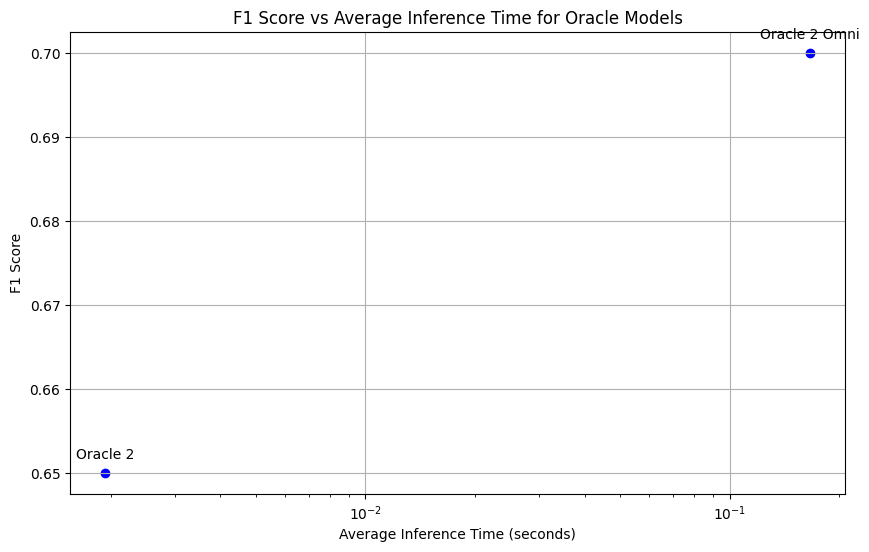

In [20]:
# make f1 vs throughput plot
models = list(F1_scores.keys())
f1_scores = list(F1_scores.values())

throughput_times = [throughput_performance[model] for model in models]
plt.figure(figsize=(10, 6))
plt.scatter(throughput_times, f1_scores, color='blue')
for i, model in enumerate(models):
    plt.annotate(model, (throughput_times[i], f1_scores[i]), textcoords="offset points", xytext=(0,10), ha='center')
plt.xlabel('Average Inference Time (seconds)')
plt.ylabel('F1 Score')
plt.title('F1 Score vs Average Inference Time for Oracle Models')
plt.xscale('log')
plt.grid()
plt.show()

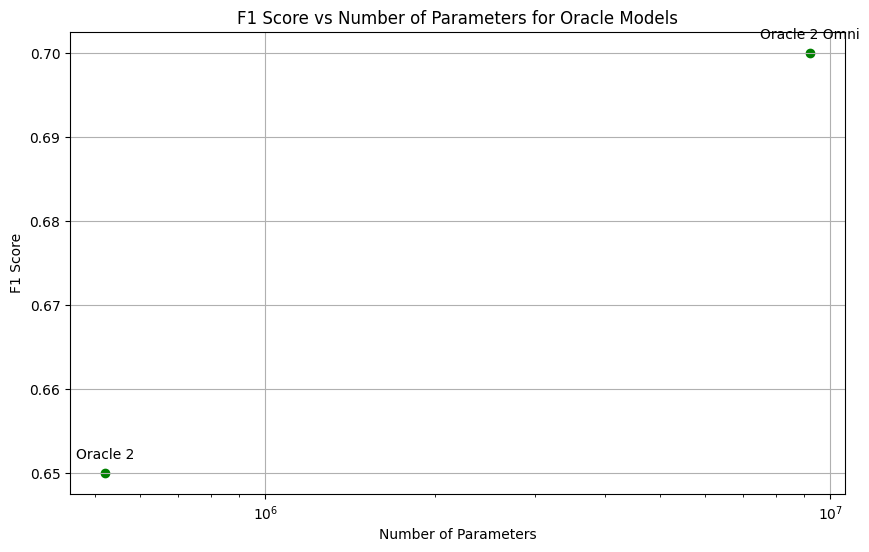

In [21]:
# plot the f1 vs parameter count
param_counts_list = [param_counts[model] for model in models]
plt.figure(figsize=(10, 6))
plt.scatter(param_counts_list, f1_scores, color='green')
for i, model in enumerate(models):
    plt.annotate(model, (param_counts_list[i], f1_scores[i]), textcoords="offset points", xytext=(0,10), ha='center')
plt.xlabel('Number of Parameters')
plt.ylabel('F1 Score')
plt.title('F1 Score vs Number of Parameters for Oracle Models')
plt.xscale('log')
plt.grid()
plt.show()